## MISA (2024-2025)
- Alohan'ny mamerina dia avereno atao Run ny notebook iray manontolo. Ny fanaovana azy dia redémarrena mihitsy ny kernel aloha (jereo menubar, safidio **Kernel$\rightarrow$Restart Kernel and Run All Cells**).

- Izay misy hoe `YOUR CODE HERE` na `YOUR ANSWER HERE` ihany no fenoina. Afaka manampy cells vaovao raha ilaina. Aza adino ny mameno references eo ambany raha ilaina.

## References
Eto ilay references rehetra no apetraka

---

In [6]:
# AZA MANAMPY CODE ATO FA MNAOVA CELLULE VAOVAO

from random import randrange
import numpy as np
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.datasets import load_diabetes, load_iris, load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

# K-Nearest Neighbor

## Computing distances

### Explication du K-Nearest Neighbors (KNN)

**Qu'est-ce que KNN?**
- Algorithme simple d'apprentissage supervisé (classification/régression)
- Utilise la proximité des points : prédire basé sur les k voisins les plus proches

**Comment ça fonctionne:**
1. **Calcul des distances** : Distance euclidienne entre chaque point test et tous les points d'entraînement
   - Distance 2-boucles : O(n²) - simple mais lent
   - Distance 1-boucle : O(n) - une boucle vectorisée
   - Distance 0-boucle : O(1) - totalement vectorisé (plus rapide!)

2. **Trouver les k plus proches voisins** (k-Nearest Neighbors)
   - Trier les distances et prendre les k plus petites

3. **Vote/Prédiction** : 
   - Pour la classification : prendre le label **le plus fréquent**
   - Pour la régression : prendre la **moyenne**

**Formule de Distance Euclidienne:**
$$d(x_i, x_j) = \sqrt{\sum_{l=1}^{D} (x_{i,l} - x_{j,l})^2}$$

**Formule Vectorisée (pour éviter les boucles):**
$$||a - b||^2 = ||a||^2 - 2ab^T + ||b||^2$$

**Avantages :**
- Simple à comprendre et implémenter
- Pas de phase d'entraînement (lazy learner)
- Bon pour données non-linéaires

**Inconvénients :**
- Lent lors de la prédiction (O(n) par test point)
- Sensible au choix de k
- Sensible à l'échelle des features (nécessite normalisation)

---

### Comparaison des 3 Approches pour Calculer les Distances

#### **1️⃣ Distance 2-Boucles (Two-Loops)**
```python
for i in range(num_test):
    for j in range(num_train):
        distance[i,j] = sqrt(sum((X_test[i] - X_train[j])^2))
```
- **Complexité :** O(n²) très lent
- **Avantage :** Simple à comprendre
- **Inconvénient :** Très lent pour grandes données
- **Usage :** Prototype/debug seulement

#### **2️⃣ Distance 1-Boucle (One-Loop)**  
```python
for i in range(num_test):
    distances[i, :] = sqrt(sum((X_test[i] - X_train)^2, axis=1))
```
- **Complexité :** O(n) - mucho más rapido
- **Technique :** Broadcasting NumPy
- **Avantage :** Équilibre entre clarté et performance
- **Usage :** Cas général

#### **3️⃣ Distance 0-Boucle (Zero-Loop) - PLUS RAPIDE ⚡**
```python
# Formule : ||a - b||^2 = ||a||^2 - 2*ab^T + ||b||^2
sum_X_test = sum(X_test^2, axis=1)       # shape: (n, 1)
sum_X_train = sum(X_train^2, axis=1)^T   # shape: (1, m)
prod = X_test @ X_train.T                # shape: (n, m)

distances = sqrt(sum_X_test - 2*prod + sum_X_train)
```
- **Complexité :** O(1) - Vectorisé complètement!
- **Avantage :** Très rapide (GPU-friendly)
- **Inconvénient :** Plus difficile à comprendre
- **Usage :** Production / grandes données

---

### Résumé des Étapes du KNN

| Étape | Operation | Complexité |
|-------|-----------|-----------|
| 1. **Calculer distances** | Toutes les distances test-train | O(n·m·D) |
| 2. **Trier distances** | np.argsort() | O(nm·log(nm)) |
| 3. **Prendre k premiers** | distances[i][:k] | O(k) |
| 4. **Voter label** | np.bincount() + argmax() | O(k) |
| **Total (par test)** | - | O(nm·log(nm)) |

où n = num_test, m = num_train, D = num_features, k = k_neighbors

In [7]:
data = load_digits()
X_train3, y_train3 = data.data, data.target
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_train3, y_train3, test_size=0.33, random_state=2)

def get_distances_two_loops_with_norm(X_train, X_test):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        for j in range(num_train):
            distances[i, j] = np.linalg.norm(X_test[i] - X_train[j])
    return distances

In [8]:
def get_distances_two_loops(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        for j in range(num_train):
            # Calculer la distance euclidienne: sqrt(sum((x - y)^2))
            distances[i, j] = np.sqrt(np.sum((X_test[i] - X_train[j]) ** 2))
    return distances

In [9]:
distances = get_distances_two_loops(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


In [10]:
def compute_distances_one_loop(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - dists: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))
    for i in range(num_test):
        # Vectoriser le calcul pour tous les points d'entraînement
        # ||X_test[i] - X_train||^2 = sum((X_test[i] - X_train)^2, axis=1)
        distances[i, :] = np.sqrt(np.sum((X_test[i] - X_train) ** 2, axis=1))
    return distances    

In [11]:
distances = compute_distances_one_loop(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


In [12]:
def get_distances_zero_loop(X_train, X_test):
    """
    Compute the distance between each test point in X_test and each training point
    in X_train 

    Inputs:
    - X_test: array of shape (num_test, D) 

    Returns:
    - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
    the ith test point and the jth training point.
    """
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    distances = np.zeros((num_test, num_train))  
    # Formule vectorisée : ||a - b||^2 = ||a||^2 - 2*a*b^T + ||b||^2
    # Cette formule permet de calculer toutes les distances sans boucle
    
    # ||X_test||^2 pour chaque point test: shape (num_test, 1)
    sum_X_test = np.sum(X_test ** 2, axis=1, keepdims=True)
    # ||X_train||^2 pour chaque point train: shape (1, num_train)
    sum_X_train = np.sum(X_train ** 2, axis=1, keepdims=True).T
    # X_test * X_train^T: shape (num_test, num_train)
    prod = np.dot(X_test, X_train.T)
    
    # Calculer les distances : sqrt(||a||^2 - 2*a*b^T + ||b||^2)
    distances = np.sqrt(sum_X_test - 2 * prod + sum_X_train)
    
    return distances

In [13]:
distances = get_distances_zero_loop(X_train3, X_test3)
true_distances = get_distances_two_loops_with_norm(X_train3, X_test3)

difference = np.linalg.norm(distances - true_distances, ord='fro')

print(difference)
assert difference < 1e-10

0.0


## K-Nearest Neighbor (knn) classifier

In [14]:
class KNearestNeighborClassifier():
    """ kNN classifier using L2 distance """

    def __init__(self, k=1):
        """
        Inputs:
        - k: number of nearest neighbors that vote for the predicted labels.
        """
        self.k = k

    def fit(self, X, y):
        """
        Train the classifier. Just memorize the training data.

        Inputs:
        - X: array of shape (num_train, D) 
        - y: array of shape (N,) 
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """
        Predict labels for test data using this classifier.

        Inputs:
        - X: array of shape (num_test, D) 

        Returns:
        - y: array of shape (num_test,) 
        """
        distances = get_distances_zero_loop(self.X_train, X)
        return self.predict_labels(distances)

    def predict_labels(self, distances):
        """
        Given a matrix of distances between test points and training points,
        predict a label for each test point.

        Inputs:
        - distances: array of shape (num_test, num_train), dists[i, j] is Euclidean distance between 
        the ith test point and the jth training point.

        Returns:
        - y:  array of shape (num_test,) 
        """
        num_test = distances.shape[0]
        y_pred = np.zeros(num_test)
        for i in range(num_test):
            # list storing the labels of the k nearest neighbors to the ith test point.
            closest_y = []

            # Trouver les indices des k plus proches voisins
            # np.argsort retourne les indices triés par distance croissante
            # Prendre les k premiers indices
            k_nearest_indices = np.argsort(distances[i])[:self.k]
            closest_y = self.y_train[k_nearest_indices]

            # Trouver le label le plus fréquent (mode)
            # Utiliser np.bincount pour compter les occurrences
            # np.argmax retourne l'index du label avec le plus d'occurrences
            y_pred[i] = np.argmax(np.bincount(closest_y.astype(int)))

        return y_pred

In [15]:
sk_model = KNeighborsClassifier(n_neighbors=3)
sk_model.fit(X_train3, y_train3)
sk_pred = sk_model.predict(X_test3)
sk_accuracy = accuracy_score(y_test3, sk_pred)

model = KNearestNeighborClassifier(k=3)
model.fit(X_train3, y_train3)
pred = model.predict(X_test3)
model_accuracy = accuracy_score(y_test3, pred)

print("Accuracy scikit-learn:", sk_accuracy)
print("Accuracy gradient descent model :", model_accuracy)
assert sk_accuracy - model_accuracy < 1e-10

Accuracy scikit-learn: 0.9831649831649831
Accuracy gradient descent model : 0.9831649831649831


## cross-validation

In [16]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []

# Split up the data into folds
# X_train_folds and y_train_folds lists of length num_folds
split_size = len(X_train3) // num_folds
for i in range(num_folds):
    start_idx = i * split_size
    end_idx = (i + 1) * split_size if i < num_folds - 1 else len(X_train3)
    X_train_folds.append(X_train3[start_idx:end_idx])
    y_train_folds.append(y_train3[start_idx:end_idx])

# A dictionary holding the accuracies for different values of k 
k_to_accuracies = {k: [] for k in k_choices}

# Faire le k-fold cross validation
for k in k_choices:
    for fold in range(num_folds):
        # Validation set = fold courant
        X_val = X_train_folds[fold]
        y_val = y_train_folds[fold]
        
        # Training set = tous les autres folds
        X_tr = np.vstack([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_tr = np.hstack([y_train_folds[i] for i in range(num_folds) if i != fold])
        
        # Entraîner le modèle avec k voisins
        classifier = KNearestNeighborClassifier(k=k)
        classifier.fit(X_tr, y_tr)
        y_pred = classifier.predict(X_val)
        accuracy = np.mean(y_pred == y_val)
        
        k_to_accuracies[k].append(accuracy)

In [17]:
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.991667
k = 1, accuracy = 0.983333
k = 1, accuracy = 0.983333
k = 1, accuracy = 0.970833
k = 1, accuracy = 0.995885
k = 3, accuracy = 0.987500
k = 3, accuracy = 0.983333
k = 3, accuracy = 0.987500
k = 3, accuracy = 0.970833
k = 3, accuracy = 0.983539
k = 5, accuracy = 0.991667
k = 5, accuracy = 0.983333
k = 5, accuracy = 0.987500
k = 5, accuracy = 0.979167
k = 5, accuracy = 0.983539
k = 8, accuracy = 0.979167
k = 8, accuracy = 0.970833
k = 8, accuracy = 0.987500
k = 8, accuracy = 0.966667
k = 8, accuracy = 0.983539
k = 10, accuracy = 0.983333
k = 10, accuracy = 0.970833
k = 10, accuracy = 0.979167
k = 10, accuracy = 0.966667
k = 10, accuracy = 0.975309
k = 12, accuracy = 0.983333
k = 12, accuracy = 0.975000
k = 12, accuracy = 0.979167
k = 12, accuracy = 0.962500
k = 12, accuracy = 0.979424
k = 15, accuracy = 0.983333
k = 15, accuracy = 0.962500
k = 15, accuracy = 0.983333
k = 15, accuracy = 0.966667
k = 15, accuracy = 0.958848
k = 20, accuracy = 0.966667
k = 20, accu

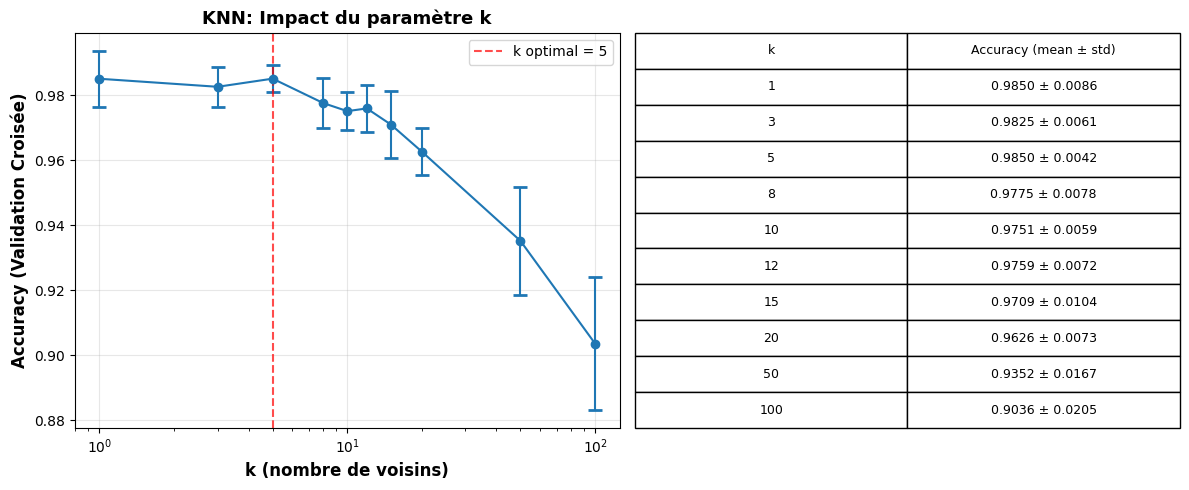

RÉSUMÉ DU K-FOLD CROSS VALIDATION
Nombre de folds: 5
k optimal trouvé: 5
Meilleure accuracy: 0.9850


In [18]:
import matplotlib.pyplot as plt

# Visualiser les résultats du cross-validation
plt.figure(figsize=(12, 5))

# Calculer les moyennes et écarts-types des accuracies
mean_accuracies = []
std_accuracies = []

for k in sorted(k_to_accuracies.keys()):
    accuracies = k_to_accuracies[k]
    mean_accuracies.append(np.mean(accuracies))
    std_accuracies.append(np.std(accuracies))

k_values = sorted(k_to_accuracies.keys())

# Graphique 1: Accuracies vs k
plt.subplot(1, 2, 1)
plt.errorbar(k_values, mean_accuracies, yerr=std_accuracies, marker='o', capsize=5, capthick=2)
plt.xlabel('k (nombre de voisins)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (Validation Croisée)', fontsize=12, fontweight='bold')
plt.title('KNN: Impact du paramètre k', fontsize=13, fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)

# Trouver le k optimal
best_k_idx = np.argmax(mean_accuracies)
best_k = k_values[best_k_idx]
best_accuracy = mean_accuracies[best_k_idx]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k optimal = {best_k}')
plt.legend()

# Graphique 2: Tableau des résultats
plt.subplot(1, 2, 2)
plt.axis('off')
table_data = []
for k in sorted(k_to_accuracies.keys()):
    acc_mean = np.mean(k_to_accuracies[k])
    acc_std = np.std(k_to_accuracies[k])
    table_data.append([f'{k}', f'{acc_mean:.4f} ± {acc_std:.4f}'])

table = plt.table(cellText=table_data, 
                  colLabels=['k', 'Accuracy (mean ± std)'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

print("="*60)
print("RÉSUMÉ DU K-FOLD CROSS VALIDATION")
print("="*60)
print(f"Nombre de folds: {num_folds}")
print(f"k optimal trouvé: {best_k}")
print(f"Meilleure accuracy: {best_accuracy:.4f}")
print("="*60)